In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

print("Path to dataset files:", path)

C:\Users\18045\Documents\AI_ML_Training\Project\StudentPerformaceML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\18045\.cache\kagglehub\datasets\lainguyn123\student-performance-factors\versions\9


In [2]:
import numpy as np # for mathematical operations
import pandas as pd
import matplotlib_inline
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv('C:/Users/18045/.cache/kagglehub/datasets/lainguyn123/student-performance-factors/versions/9/StudentPerformanceFactors.csv')

In [5]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
df.shape
y=df['Exam_Score']
print(y)

0       67
1       61
2       74
3       71
4       70
        ..
6602    68
6603    69
6604    68
6605    68
6606    64
Name: Exam_Score, Length: 6607, dtype: int64


Remove duplicates

In [7]:
df.drop_duplicates()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [8]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Exploring Data

In [11]:
print("Categories in gender")
print(df['Gender'].unique())
print("Categories in School Type")
print(df['School_Type'].unique())

Categories in gender
['Male' 'Female']
Categories in School Type
['Public' 'Private']


In [12]:
# define numerical and categorical values
numeric_features=[feature for feature in df.columns if df[feature].dtype == 'object']
categorical_features=[feature for feature in df.columns if df[feature].dtype != 'object']

print('We have {} numeric features'.format(len(numeric_features)))
print('We have {} categorical features'.format(len(categorical_features)))

We have 13 numeric features
We have 7 categorical features


In [13]:
# Check Missing Values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [14]:
def clean_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Automatically handles missing values in both numerical and categorical columns.

    - Numerical columns -> fill with mean
    - Categorical columns -> fill with mode (most frequent value)
      (if mode is not available, fills with "Unknown")

    Returns a cleaned copy of the DataFrame.
    """
    df_clean = df.copy()

    for col in df_clean.columns:
        if df_clean[col].dtype in ["int64", "float64"]:  # Numerical
            df_clean[col].fillna(df_clean[col].mean(), inplace=True)
        else:  # Categorical / object / string
            if df_clean[col].mode().empty:
                df_clean[col].fillna("Unknown", inplace=True)
            else:
                df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

    return df_clean


In [15]:
# Suppose df has both numeric & categorical columns with NaN
print("Missing values before cleaning:\n", df.isnull().sum())
df_clean = clean_missing_values(df)
print("----------------------------------")
print("Missing values after cleaning:\n", df_clean.isnull().sum())


Missing values before cleaning:
 Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
----------------------------------
Missing values after cleaning:
 Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Mot

C:\Users\18045\AppData\Local\Temp\ipykernel_20172\1708348438.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mean(), inplace=True)
C:\Users\18045\AppData\Local\Temp\ipykernel_20172\1708348438.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [16]:
import matplotlib_inline
import matplotlib.pyplot as plt
import seaborn as sns

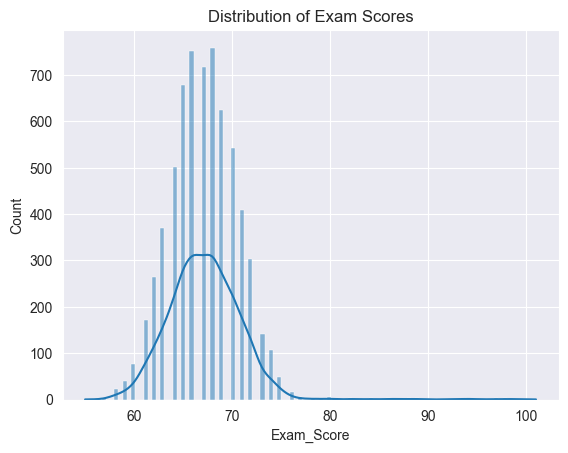

In [17]:
# 1. Score distribution
sns.histplot(df['Exam_Score'], kde=True)
plt.title("Distribution of Exam Scores")
plt.show()

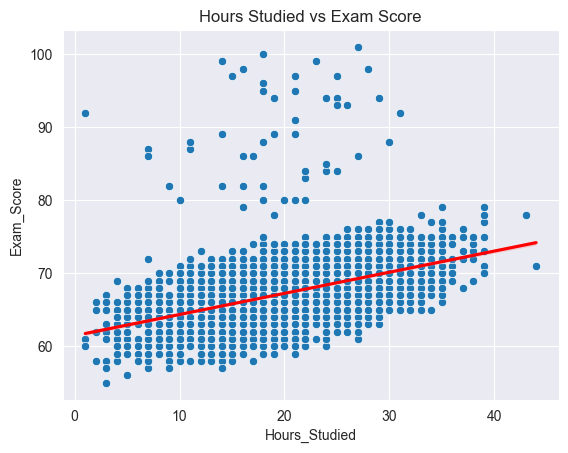

In [18]:
# 2. Hours studied vs Exam Score
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df, scatter=False, color='red')
plt.title("Hours Studied vs Exam Score")
plt.show()

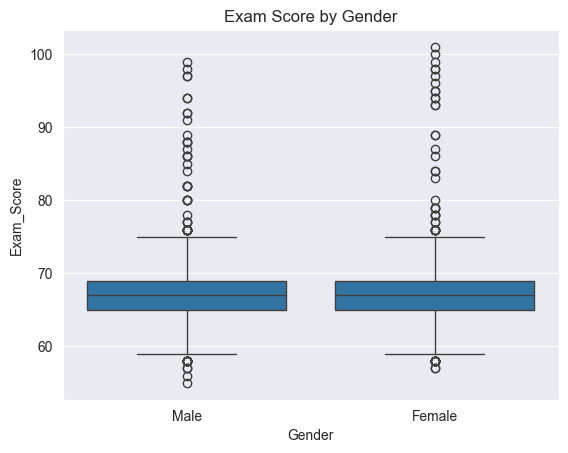

In [19]:
sns.boxplot(x='Gender', y='Exam_Score', data=df)
plt.title("Exam Score by Gender")
plt.show()

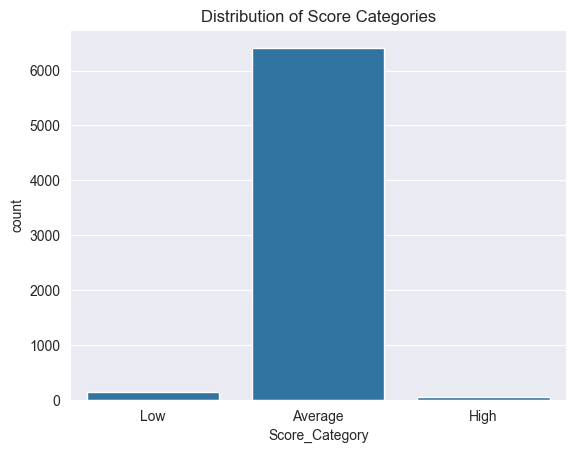

In [15]:
# 4. Exam Score categories
df['Score_Category'] = pd.cut(df['Exam_Score'], bins=[0, 60, 80, 100], labels=['Low','Average','High'])
sns.countplot(x='Score_Category', data=df)
plt.title("Distribution of Score Categories")
plt.show()

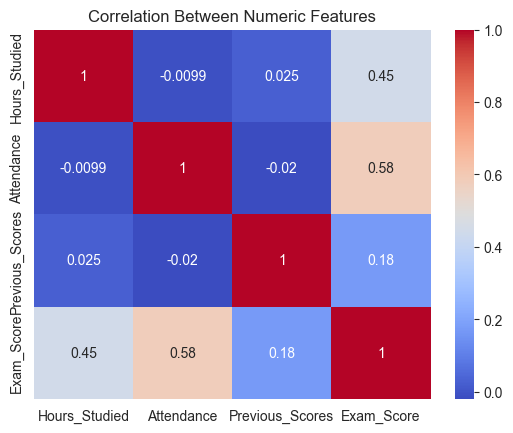

In [20]:
# 5. Correlation heatmap for numeric features
num_cols = ['Hours_Studied','Attendance','Previous_Scores','Exam_Score']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

Covariance is a statistical measure that indicates the direction of the linear relationship between two variables X and Y. It tells how Y would change for a unit change in X. Covariance > 0 → as one increases, the other tends to increase. Eg: positive, so more study hours generally mean higher exam scores.

In [20]:
# Example: covariance between Hours_Studied and Exam_Score
cov_matrix = df[['Hours_Studied', 'Exam_Score']].cov()
print("Covariance Matrix:\n", cov_matrix)
# Access just the covariance value
cov_value = cov_matrix.loc['Hours_Studied', 'Exam_Score']
print("Covariance:", cov_value)

Covariance Matrix:
                Hours_Studied  Exam_Score
Hours_Studied      35.887221   10.381837
Exam_Score         10.381837   15.135646
Covariance: 10.381836579072072


Correlation Coefficient (Pearson’s r) ; Standardized version of covariance (always between -1 and 1). Tells you both direction and strength of the relationship.

Covariance < 0 → as one increases, the other tends to decrease.

Correlation (r) closer to 1 = strong positive, closer to -1 = strong negative, near 0 = no linear relationship.

In [56]:
# Correlation matrix
corr_matrix = df[['Hours_Studied', 'Exam_Score']].corr()
print("Correlation Matrix:\n", corr_matrix)

# Just the correlation value
corr_value = corr_matrix.loc['Hours_Studied', 'Exam_Score']
print("Correlation Coefficient:", corr_value)


Correlation Matrix:
                Hours_Studied  Exam_Score
Hours_Studied       1.000000    0.445455
Exam_Score          0.445455    1.000000
Correlation Coefficient: 0.44545495407528174
